# AccessMap: Housing and Accessibility

## Project Description
This notebook explores the "Housing and Accessibility" dataset. Workers
looked at 10,000 Google Maps images. They marked if each area is
residential. If yes, they wrote down the house type (private house or
apartment) and if sidewalks looked wheelchair-friendly. This is notebook 2
of 3. This one covers the Housing dataset only.

## Dataset
- **Source:** Kaggle - peacehegemony
- **File:** housing-wheelchairs-DFE.csv
- **Link:** https://www.kaggle.com/datasets/peacehegemony/housing-and-accessibility

## Project Roadmap

| Step | What to do |
|---|---|
| 1. Explore Dataset | Load csv, check shape and columns |
| 2. Data Cleaning | Duplicates, missing values, confidence scores |
| 3. Bias Analysis | Geographic, missing data, subjective labeling bias |
| 3b. Bias Audit | Check bias with real numbers |
| 4. Feature Exploration + Visualization | House type counts, sidewalk chart, location map |
| 5. Export Clean Data | Save clean data for the merge notebook |


In [2]:
# Step 1: Explore Dataset (Housing and Accessibility)
# Goal: load the csv, look at it before cleaning.
import pandas as pd

CSV_PATH = '../data/raw/housing-wheelchairs-DFE.csv'

# This file uses latin-1 encoding. utf-8 throws an error here.
df = pd.read_csv(CSV_PATH, encoding='latin-1')

# CHANGED: readable shape instead of a raw tuple
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

# Show column name + data type together, one per line.
print("\n--------------------------------------- Columns + Data Types ---------------------------------------")
print(df.dtypes.to_frame('Data Type'))

# === First 5 Rows ===
print("\n--------------------------------------- First 5 Rows ---------------------------------------")
display(df.head().T)

Shape: 10,104 rows x 21 columns

--------------------------------------- Columns + Data Types ---------------------------------------
                            Data Type
_unit_id                        int64
_golden                          bool
_unit_state                    object
_trusted_judgments              int64
_last_judgment_at              object
house_types                    object
house_types:confidence        float64
residential_yes                object
residential_yes:confidence    float64
sidewalk_ok                    object
sidewalk_ok:confidence        float64
aadress                        object
house_types_gold               object
house_types_gold_reason        object
lat                           float64
long                          float64
residential_yes_gold           object
residential_yes_gold_reason    object
sidewalk_ok_gold               object
sidewalk_ok_gold_reason        object
url                            object

-----------------------------

,0,1,2,3,4
_unit_id,752055128,752055129,752055130,752055131,752055132
_golden,True,True,True,True,True
_unit_state,golden,golden,golden,golden,golden
_trusted_judgments,25,26,25,23,22
_last_judgment_at,NaN,NaN,NaN,NaN,NaN
house_types,private_house,private_house,private_house,private_house,private_house
house_types:confidence,1.0,1.0,0.9642,1.0,0.9174
residential_yes,yes,yes,yes,yes,yes
residential_yes:confidence,1.0,1.0,0.9642,1.0,0.9174
sidewalk_ok,yes,no,yes,yes,yes


## Step 1 Summary - Explore Dataset (Housing and Accessibility)

### What we did:
- Loaded the CSV (latin-1 encoding).
- Looked at column names, data types, and the first 5 rows (transposed).

### What we found:
- 10,104 rows, 21 columns. Each row is one image a worker looked at.
- Main columns: `residential_yes` (is this area residential), `house_types`
  (private_house / apartment_blocks / other), `sidewalk_ok` (is the
  sidewalk wheelchair-friendly), `lat`, `long`, `aadress`, `url`
- `_golden` rows (104 of them) are test rows with a known right answer.
  Used to check worker quality.
- `*_gold` and `*_gold_reason` columns hold the right answer for golden
  rows only. Blank for the rest.

### What this means:
- This data comes from human judgment, not sensors like PMR. So worker
  confidence matters more here.
- Data has `lat` and `long`. We can map it, same as PMR.

### Next step:
-> Step 2: Data Cleaning

In [3]:
# Step 2: Data Cleaning (Housing and Accessibility)
import pandas as pd

CSV_PATH = '../data/raw/housing-wheelchairs-DFE.csv'
df = pd.read_csv(CSV_PATH, encoding='latin-1')

# ---------------------------------------------------------
# 2.1 Duplicates
# ---------------------------------------------------------
print("-------------------- Duplicates --------------------")
dup_mask = df.duplicated()
n_dup = dup_mask.sum()
n_before = len(df)
print(f"Duplicate rows: {n_dup:,} ({n_dup/n_before:.1%} of data)")
df = df[~dup_mask]
print(f"After removing duplicates: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Duplicate _unit_id: {df['_unit_id'].duplicated().sum()}")

# ---------------------------------------------------------
# 2.2 Drop columns we don't need
# ---------------------------------------------------------
reason_cols = [c for c in df.columns if c.endswith('_reason')]
print(f"\nDropping reason columns: {reason_cols}")
df = df.drop(columns=reason_cols)

# ---------------------------------------------------------
# 2.3 Missing values, split by row type
# ---------------------------------------------------------
n_total = len(df)
print("\n-------------------- Missing Values (overall) --------------------")
for col, cnt in df.isnull().sum().sort_values(ascending=False).items():
    if cnt > 0:
        print(f"  {col:<28} {cnt:>6,} ({cnt/n_total:.1%})")

print("\n-------------------- Missing Values: residential rows only --------------------")
residential_rows = df[df['residential_yes'] == 'yes']
n_res = len(residential_rows)
print(f"({n_res:,} residential rows)")
for col in ['house_types', 'sidewalk_ok']:
    cnt = residential_rows[col].isnull().sum()
    print(f"  {col:<28} {cnt:>6,} ({cnt/n_res:.1%})")
print("-> Should be close to 0%. Confirms this missing pattern is expected.")

# ---------------------------------------------------------
# 2.4 Data quality flag: confidence scores
# ---------------------------------------------------------
print("\n-------------------- Confidence Score Summary --------------------")
conf_cols = [c for c in df.columns if 'confidence' in c]
for col in conf_cols:
    s = df[col].dropna()
    print(f"  {col:<28} mean={s.mean():.3f}  min={s.min():.3f}  "
          f"median={s.median():.3f}  n={len(s):,}")

df['low_confidence_residential'] = df['residential_yes:confidence'] < 0.7
n_low = df['low_confidence_residential'].sum()
print(f"\nLow-confidence residential_yes rows: {n_low:,} ({n_low/n_total:.1%} of data)")

# ---------------------------------------------------------
# 2.5 Final check
# ---------------------------------------------------------
print("\n-------------------- Clean Dataset Ready --------------------")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

-------------------- Duplicates --------------------
Duplicate rows: 0 (0.0% of data)
After removing duplicates: 10,104 rows x 21 columns
Duplicate _unit_id: 0

Dropping reason columns: ['house_types_gold_reason', 'residential_yes_gold_reason', 'sidewalk_ok_gold_reason']

-------------------- Missing Values (overall) --------------------
  sidewalk_ok_gold             10,065 (99.6%)
  house_types_gold             10,053 (99.5%)
  residential_yes_gold         10,001 (99.0%)
  house_types                   3,654 (36.2%)
  sidewalk_ok                   3,653 (36.2%)
  sidewalk_ok:confidence        3,647 (36.1%)
  house_types:confidence        3,647 (36.1%)
  _last_judgment_at               104 (1.0%)

-------------------- Missing Values: residential rows only --------------------
(6,451 residential rows)
  house_types                       1 (0.0%)
  sidewalk_ok                       0 (0.0%)
-> Should be close to 0%. Confirms this missing pattern is expected.

-------------------- Confid

## Step 2 Summary - Data Cleaning (Housing and Accessibility)

### What we did:
- Removed exact duplicate rows. Checked `_unit_id` is unique.
- Dropped free-text "_reason" columns. Not useful for modeling.
- Checked missing values inside residential rows only, not the whole table.
- Flagged rows where `residential_yes:confidence` is low.

### What we found:
- Duplicate rows: 0 (0.0%). `_unit_id` has 0 duplicates.
- After removing duplicates: 10,104 rows x 21 columns.
- Missing values (overall): `sidewalk_ok_gold` 99.6%, `house_types_gold`
  99.5%, `residential_yes_gold` 99.0%, `house_types` 36.2%, `sidewalk_ok`
  36.2%, `sidewalk_ok:confidence` 36.1%, `house_types:confidence` 36.1%,
  `_last_judgment_at` 1.0%.
- Missing values (residential rows only, 6,451 rows): `house_types`
  missing 1 (0.0%), `sidewalk_ok` missing 0 (0.0%). Confirms the missing
  pattern is expected — `house_types`/`sidewalk_ok` are blank only for
  non-residential rows.
- Confidence scores: `house_types:confidence` mean 0.999,
  `residential_yes:confidence` mean 1.000 (min 0.839),
  `sidewalk_ok:confidence` mean 0.998. Workers agreed almost every time.
- Low-confidence `residential_yes` rows: 0 (0.0%).
- Final clean dataset: 10,104 rows x 19 columns.

### Next step:
-> Step 3: Bias Analysis

## Step 3: Bias Analysis (Housing and Accessibility)

### What is bias?
Bias means the data or model may not be fair or correct for every case.

### Note on our proposal's 3 bias types:
Our proposal listed **Geographic Bias**, **Missing Data Bias**, and
**Subjective Labeling Bias**. All three fit this dataset:
- **Geographic Bias:** images have real addresses (`aadress`, `lat`,
  `long`). If some regions have way more images than others, results
  won't generalize everywhere. We check this two ways: by state, and
  by city (as a rural vs. urban proxy -- big cities get many images,
  small towns get 1 or 2).
- **Missing Data Bias:** `house_types` and `sidewalk_ok` are only filled
  for residential areas. Non-residential areas have no accessibility
  label at all.
- **Subjective Labeling Bias:** `sidewalk_ok` is a human guess from a
  photo, not a measurement. Workers can disagree on what counts as
  "wheelchair-friendly." Notebook 01 swapped this out for Width
  Estimation Bias, because PMR's width data is measured, not opinion.
  It belongs here instead.

### Next step:
-> Step 3b: Bias Audit


In [4]:
# Step 3b: Bias Audit (Housing and Accessibility)
# Identifying & Mitigating Data Bias
# Goal: check bias with numbers, not just words.
import pandas as pd

CSV_PATH = '../data/raw/housing-wheelchairs-DFE.csv'
df = pd.read_csv(CSV_PATH, encoding='latin-1')


def check_group_representation(df, group_col):
    return df[group_col].value_counts(normalize=True)


def compare_missingness_by_group(df, group_col, target_col):
    return df.groupby(group_col)[target_col].apply(lambda s: s.isnull().mean())


def compare_confidence_by_group(df, group_col, confidence_col):
    return df.groupby(group_col)[confidence_col].mean()


# CHANGED: helper to print a Series as "label: value" instead of a
# raw pandas Series with a Name/dtype footer
def print_series(series, label, as_pct=False, top_n=None):
    print(f"\n-------------------- {label} --------------------")
    s = series.head(top_n) if top_n else series
    for idx, val in s.items():
        if as_pct:
            print(f"  {idx:<20} {val:.1%}")
        else:
            print(f"  {idx:<20} {val:.3f}")


def check_city_coverage_bias(df):
    df = df.copy()
    df['city'] = df['aadress'].str.extract(r',\s*([^,]+),\s*[A-Z]{2}\s*\d{5}')
    city_counts = df['city'].value_counts()
    df['city_coverage'] = df['city'].map(
        lambda c: 'low (1-2 images)' if city_counts.get(c, 0) <= 2 else 'high (3+ images)'
    )

    n_low = (city_counts <= 2).sum()
    n_total_cities = len(city_counts)
    print(f"Cities with only 1-2 images: {n_low:,} of {n_total_cities:,} total cities "
          f"({n_low/n_total_cities:.1%})")

    print_series(df['city_coverage'].value_counts(normalize=True),
                 "Share of rows by city coverage", as_pct=True)
    print_series(df.groupby('city_coverage')['sidewalk_ok:confidence'].mean(),
                 "Average sidewalk_ok confidence by city coverage")


# --- 1. Representation check: how balanced are house types? ---
print_series(check_group_representation(df, 'house_types'),
             "Representation by house_types", as_pct=True)

# --- 2. Geographic Bias check: how many images per state? ---
df['state'] = df['aadress'].str.extract(r',\s*([A-Z]{2})\s*\d{5}')
print_series(check_group_representation(df, 'state'),
             "Representation by state (top 10)", as_pct=True, top_n=10)

# --- 3. Missing Data Bias check: house_types missing rate by residential_yes ---
print_series(compare_missingness_by_group(df, 'residential_yes', 'house_types'),
             "Missing house_types rate by residential_yes", as_pct=True)

# --- 4. Subjective Labeling Bias check: confidence by house type ---
print_series(compare_confidence_by_group(df, 'house_types', 'sidewalk_ok:confidence'),
             "Average sidewalk_ok confidence by house_types")

# --- 5. Geographic Bias check, part 2: rural vs. urban proxy ---
print("\n-------------------- City Coverage Bias (rural vs. urban proxy) --------------------")
check_city_coverage_bias(df)


-------------------- Representation by house_types --------------------
  private_house        98.0%
  apartment_blocks     1.9%
  other                0.1%

-------------------- Representation by state (top 10) --------------------
  CA                   24.6%
  TX                   8.0%
  MI                   7.4%
  IL                   7.2%
  AZ                   6.3%
  CO                   4.9%
  NY                   4.9%
  OH                   4.7%
  FL                   4.4%
  NJ                   4.0%

-------------------- Missing house_types rate by residential_yes --------------------
  no                   100.0%
  not_avail            100.0%
  yes                  0.0%

-------------------- Average sidewalk_ok confidence by house_types --------------------
  apartment_blocks     0.996
  other                1.000
  private_house        0.999

-------------------- City Coverage Bias (rural vs. urban proxy) --------------------
Cities with only 1-2 images: 562 of 1,170 total 

## Step 3 Summary - Data Bias (Housing and Accessibility)

### How we reduce bias:
- Report results for residential and non-residential areas separately.
- Flag low-confidence rows instead of trusting every label.
- Cross-check with the PMR dataset when possible. Both cover
  accessibility, but from different angles.

### Bias audit results:
- House type is very unbalanced: private_house 98.0%, apartment_blocks
  1.9%, other 0.1%. Apartments barely show up in this data.
- Top states: CA 24.6%, TX 8.0%, MI 7.4%, IL 7.2%, AZ 6.3%. CA alone is
  a quarter of the whole dataset. Big state-level imbalance.
- City coverage (rural vs. urban proxy): 562 of 1,170 cities have only
  1-2 images, but those cities make up just 8.4% of all rows. Big
  cities (3+ images) make up 91.6%. Small towns are underrepresented.
- house_types is missing 100% for non-residential rows ("no" and
  "not_avail"). Confirms the missing pattern is by design, not random.
- Confidence stays high across house types (0.996-1.0) and across city
  coverage groups (0.992-0.999). No group shows a real trust gap.

### What this means:
- Any model result about apartments or "other" house types is not
  reliable. Too few samples.
- Any result about small states or small towns is weaker than results
  about CA, TX, or big cities. Treat those claims with caution.

### Next step:
-> Step 4: Feature Exploration + Visualization


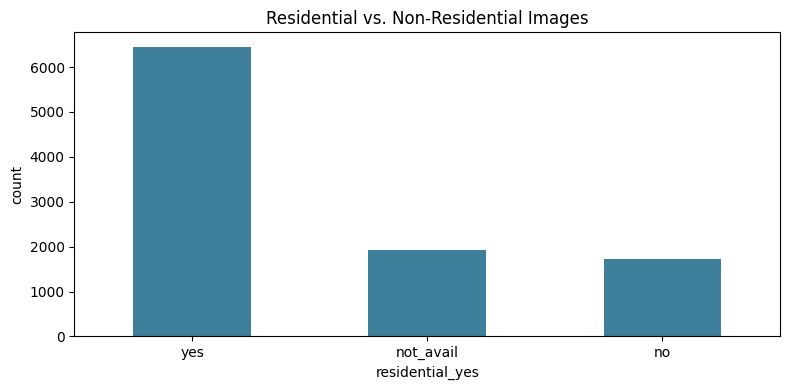

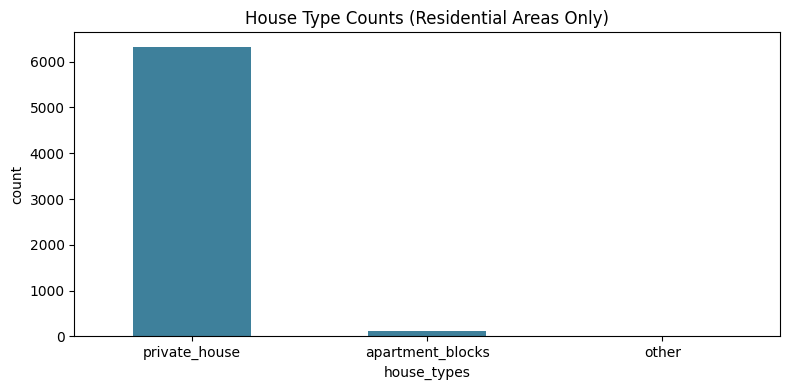

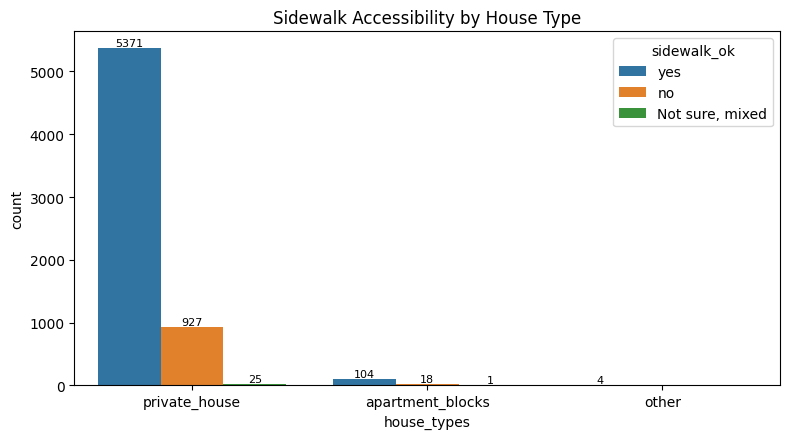

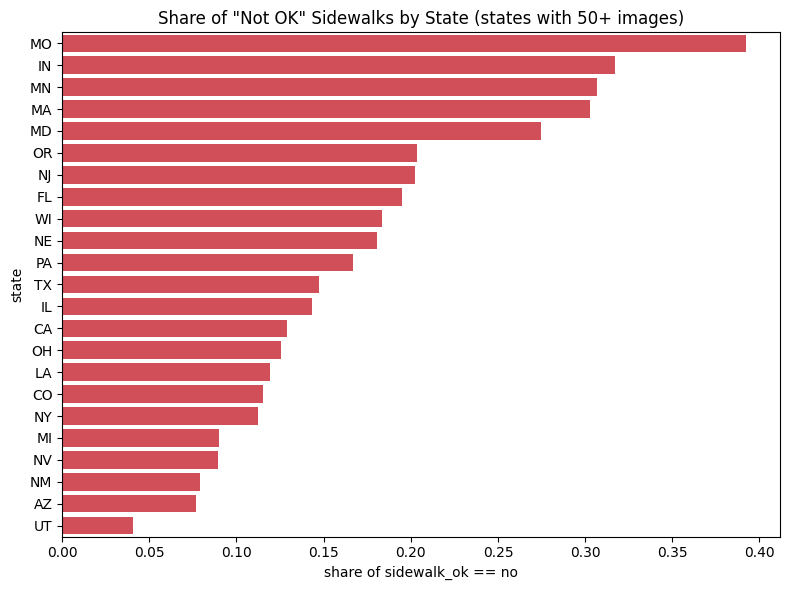

Dropped 16 row(s) with coordinates outside the US (likely bad geocoding).


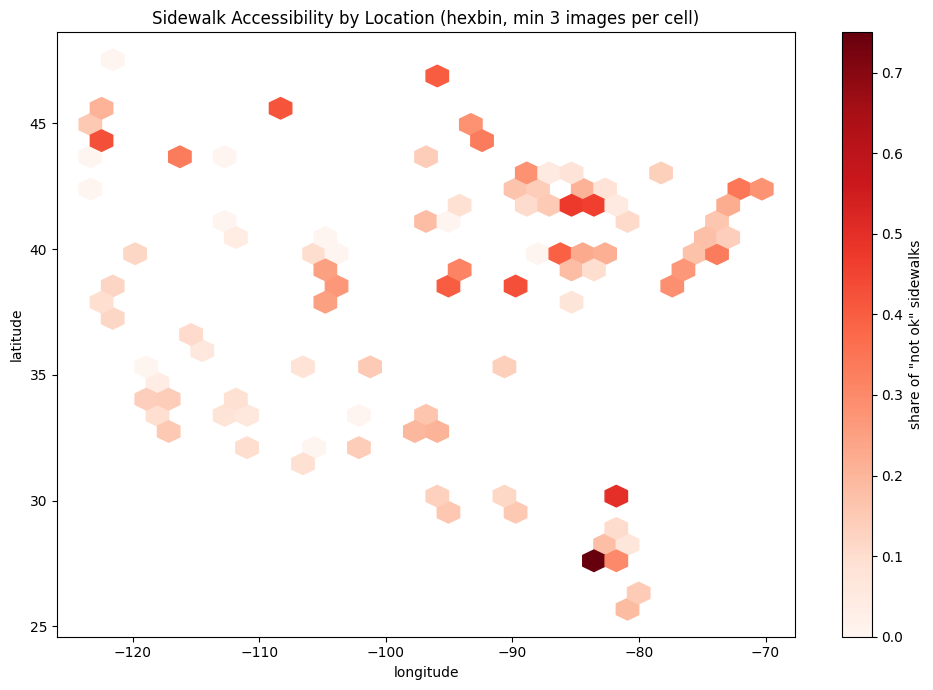

In [5]:
# Step 4: Feature Exploration + Visualization (Housing and Accessibility)
# Data Visualization Best Practices
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

CSV_PATH = '../data/raw/housing-wheelchairs-DFE.csv'
df = pd.read_csv(CSV_PATH, encoding='latin-1')


def plot_residential_counts(df):
    # Bar plot: how many images are residential vs. not.
    plt.figure(figsize=(8, 4))
    sns.countplot(x='residential_yes', data=df,
                  order=df['residential_yes'].value_counts().index,
                  color='#2E86AB', width=0.5)
    plt.title('Residential vs. Non-Residential Images')
    plt.xlabel('residential_yes')
    plt.tight_layout()
    plt.show()


def plot_house_type_counts(df):
    # Bar plot: house type counts. Residential rows only, others are NaN.
    plot_df = df[df['house_types'].notnull()]
    plt.figure(figsize=(8, 4))
    sns.countplot(x='house_types', data=plot_df,
                  order=plot_df['house_types'].value_counts().index,
                  color='#2E86AB', width=0.5)
    plt.title('House Type Counts (Residential Areas Only)')
    plt.tight_layout()
    plt.show()


def plot_sidewalk_ok_by_house_type(df):
    # Compare sidewalk_ok across house types. Shows if apartments or
    # private houses have better wheelchair access.
    # bar_label adds the exact count on top of each bar. Needed here
    # because "Not sure, mixed" is a tiny sliver (26 rows), too small
    # to read without a number.
    plot_df = df[df['sidewalk_ok'].notnull() & df['house_types'].notnull()]
    plt.figure(figsize=(8, 4.5))
    ax = sns.countplot(x='house_types', hue='sidewalk_ok', data=plot_df)
    for container in ax.containers:
        ax.bar_label(container, fontsize=8)
    plt.title('Sidewalk Accessibility by House Type')
    plt.tight_layout()
    plt.show()


def plot_sidewalk_by_state(df, min_count=50):
    # Bar chart: share of "not ok" sidewalks per state, high to low.
    # Only states with at least min_count labeled rows are shown, so
    # we don't plot a noisy 100% from a state with just 1-2 images.
    df = df.copy()
    df['state'] = df['aadress'].str.extract(r',\s*([A-Z]{2})\s*\d{5}')
    labeled = df.dropna(subset=['sidewalk_ok'])
    state_counts = labeled['state'].value_counts()
    valid_states = state_counts[state_counts >= min_count].index

    not_ok_rate = (
        labeled[labeled['state'].isin(valid_states)]
        .groupby('state')['sidewalk_ok']
        .apply(lambda s: (s == 'no').mean())
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(8, 6))
    sns.barplot(x=not_ok_rate.values, y=not_ok_rate.index, color='#E63946')
    plt.title(f'Share of "Not OK" Sidewalks by State (states with {min_count}+ images)')
    plt.xlabel('share of sidewalk_ok == no')
    plt.ylabel('state')
    plt.tight_layout()
    plt.show()


def plot_location_hexbin(df, gridsize=30):
    # Hexbin map: color = share of "not ok" sidewalks in that area.
    # Replaces the old scatter plot. A scatter plot of 3000 dots just
    # overlaps into a blob. Hexbin groups nearby points into cells and
    # colors each cell by its average, much easier to read.
    labeled = df.dropna(subset=['sidewalk_ok']).copy()
    labeled['not_ok'] = (labeled['sidewalk_ok'] == 'no').astype(int)

    # CHANGED: drop rows outside the continental US + AK/HI bounding
    # box. A few rows have bad lat/long (e.g. one lands in Europe),
    # which skews both the map and the color scale.
    US_LAT_RANGE = (18, 72)      # covers Hawaii to Alaska
    US_LONG_RANGE = (-180, -65)  # covers Alaska to the East Coast
    before = len(labeled)
    labeled = labeled[
        labeled['lat'].between(*US_LAT_RANGE) &
        labeled['long'].between(*US_LONG_RANGE)
    ]
    dropped = before - len(labeled)
    if dropped > 0:
        print(f"Dropped {dropped} row(s) with coordinates outside the US "
              f"(likely bad geocoding).")

    plt.figure(figsize=(10, 7))
    hb = plt.hexbin(labeled['long'], labeled['lat'], C=labeled['not_ok'],
                     reduce_C_function=np.mean, gridsize=gridsize, cmap='Reds', mincnt=3)
    plt.colorbar(hb, label='share of "not ok" sidewalks')
    plt.title('Sidewalk Accessibility by Location (hexbin, min 3 images per cell)')
    plt.xlabel('longitude')
    plt.ylabel('latitude')
    plt.tight_layout()
    plt.show()


# Run all plots on the Housing dataset
plot_residential_counts(df)
plot_house_type_counts(df)
plot_sidewalk_ok_by_house_type(df)
plot_sidewalk_by_state(df)
plot_location_hexbin(df)


## Step 4 Summary - Feature Exploration + Visualization (Housing and Accessibility)

### What we found:
- private_house is by far the most common house type (98% of residential rows). apartment_blocks and other are rare.
- Most private_house sidewalks are OK (5,371 yes vs. 927 no). apartment_blocks has fewer bad sidewalks too (104 yes vs. 18 no), but sample size is small.
- By state, MO has the worst sidewalk rate (39% not ok), UT the best (4%). Big spread between states.
- The hexbin map (after dropping 1 row with bad coordinates outside
  the US) shows the worst spot is near Florida (~75% not ok), with
  other clusters of bad sidewalks in the Midwest and Northeast too.
  Not spread evenly across the country.

### What this means:
- `house_types` and `sidewalk_ok` will likely help as model features.
- State and location patterns could mean real gaps, or just where more images were collected. Step 3's bias audit helps tell these apart.

### Next step:
-> Step 5: Export Clean Data

In [1]:
# Step 5: Export Clean Data (Housing and Accessibility)
import pandas as pd
import os

CSV_PATH = '../data/raw/housing-wheelchairs-DFE.csv'
df = pd.read_csv(CSV_PATH, encoding='latin-1')

# Remove duplicates one more time before saving
n_before = len(df)
df = df[~df.duplicated()]
n_dupes_dropped = n_before - len(df)

# Drop free-text reason columns. Not useful for modeling.
reason_cols = [c for c in df.columns if c.endswith('_reason')]
df = df.drop(columns=reason_cols)

# Carry over the confidence flag from Step 2 so notebook 03 doesn't have
# to recompute it. 0.7 is the same cutoff used there -- rows below this
# mean workers disagreed on whether the area was residential at all.
df['low_confidence_residential'] = df['residential_yes:confidence'] < 0.7

os.makedirs('../data/processed', exist_ok=True)
out_path = '../data/processed/housing_clean.csv'
df.to_csv(out_path, index=False)

# Readable summary block
n_low_conf = df['low_confidence_residential'].sum()
pct_low_conf = df['low_confidence_residential'].mean() * 100

print("*" * 70)
print("HOUSING DATA EXPORT SUMMARY")
print("*" * 70)
print(f"Saved to:            {out_path}")
print(f"Rows:                {df.shape[0]:,}")
print(f"Columns:             {df.shape[1]}")
print(f"Duplicates dropped:  {n_dupes_dropped:,}")
print(f"Reason cols dropped: {len(reason_cols)}")
print("-" * 70)
print("Data Quality")
print(f"  Low-confidence residential rows: {n_low_conf:,} ({pct_low_conf:.1f}%)")
print("*" * 70)

**********************************************************************
HOUSING DATA EXPORT SUMMARY
**********************************************************************
Saved to:            ../data/processed/housing_clean.csv
Rows:                10,104
Columns:             19
Duplicates dropped:  0
Reason cols dropped: 3
----------------------------------------------------------------------
Data Quality
  Low-confidence residential rows: 0 (0.0%)
**********************************************************************


## Step 5 Summary - Export Clean Data (Housing and Accessibility)

**What we did:**
- Removed the last duplicates (0 found this pass).
- Dropped 3 free-text `_reason` columns. Not useful for modeling.
- Added `low_confidence_residential` (`True` if `residential_yes:confidence` < 0.7) so downstream notebooks don't need to recompute it.
- Saved clean data to `data/processed/housing_clean.csv`.

**What we found:**
- Final shape: 10,104 rows, 19 columns (18 original + `low_confidence_residential`, minus 3 dropped reason columns).
- 0 rows (0.0%) flagged as low-confidence. Matches Step 2/3's finding that worker agreement was consistently high across this dataset — this flag exists for completeness, but won't do much filtering here.

**Next step:**
→ Notebook 03: Build features and models for PMR and Housing separately (not merged — see notebook 03 intro for why).